<a href="https://colab.research.google.com/github/genaiconference/Agentic_KAG_Workshop_DHS_2026/blob/main/03_retrieve_data_from_knowledge_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Retrieve Data from Knoweldge Graph

This notebook demonstrates a Retrieval-Augmented Generation (RAG) pipeline built using the Neo4j GraphRAG module. The workflow involves:

1.  **Data Ingestion**: Loading data into a Neo4j graph database.
2.  **Indexing**: Creating vector and full-text indexes on the graph data for efficient retrieval.
3.  **Retrieval**: Utilizing various retriever types (Vector, Vector Cypher, Hybrid, Hybrid Cypher, Text2Cypher) to fetch relevant information from the knowledge graph based on a user query.
4.  **Generation**: Using a Large Language Model (LLM) to generate an answer based on the retrieved context.

## Architecture Components

-   **Neo4j Graph Database**: Stores the knowledge graph data.
-   **Neo4j GraphRAG Module**: A Python library that facilitates building RAG applications with Neo4j.
    -   **LLM (OpenAILLM)**: Used for text generation (e.g., GPT-5-mini).
    -   **Embeddings (OpenAIEmbeddings)**: Used to create vector representations of text (e.g., text-embedding-3-small).
    -   **Indexes**:
        -   **Vector Index**: For semantic similarity search on node embeddings.
        -   **Full-text Index**: For lexical similarity search on node properties.
    -   **Retrievers**:
        -   `VectorRetriever`: Performs ANN vector search.
        -   `VectorCypherRetriever`: Combines vector search with Cypher queries for graph traversal.
        -   `HybridRetriever`: Combines vector and full-text search.
        -   `HybridCypherRetriever`: Combines vector and full-text search with Cypher queries.
        -   `Text2CypherRetriever`: Converts natural language to Cypher queries.
-   **Langfuse Handler (Optional)**: For tracing and observability of LLM interactions.

## Key Features Covered

-   **Graph Indexing**: Creation of vector and full-text indexes within Neo4j.
-   **Advanced Retrieval Strategies**: Implementation and demonstration of various retrieval mechanisms:
    -   Vector search for semantic relevance.
    -   Full-text search for lexical relevance.
    -   Cypher queries for complex graph traversal.
    -   Hybrid approaches combining vector, full-text, and Cypher.
    -   Text2Cypher for natural language to graph query translation.
-   **GraphRAG Pipeline**: Setting up and running a complete RAG pipeline to answer questions using retrieved graph context.

## Tech stack

-   **Neo4j Graph Database**: For storing and querying graph data.
-   **Neo4j GraphRAG Module**: Python library for building RAG applications with Neo4j.
-   **OpenAI**: For Large Language Models (LLMs) like GPT-5-mini and embedding models like text-embedding-3-small.
-   **Python**: The primary programming language used for the notebook.
-   **LangChain**: (Implicitly supported by `neo4j-graphrag` for LLM integrations).
-   **Langfuse**: (Optional) For LLM observability and tracing.

# Setup & Pre-Requisites

In [ ]:
!git clone https://github.com/genaiconference/Agentic_KAG_Workshop_DHS_2026.git

Cloning into 'Agentic_KAG_Workshop_DHS_2026'...
remote: Enumerating objects: 272, done.
remote: Counting objects: 100% (178/178), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 272 (delta 112), reused 50 (delta 43), pack-reused 94 (from 1)
Receiving objects: 100% (272/272), 7.27 MiB | 9.21 MiB/s, done.
Resolving deltas: 100% (141/141), done.


Upload your '.env' file inside the 'Agentic_KAG_Workshop_DHS_2026' folder in the Files section
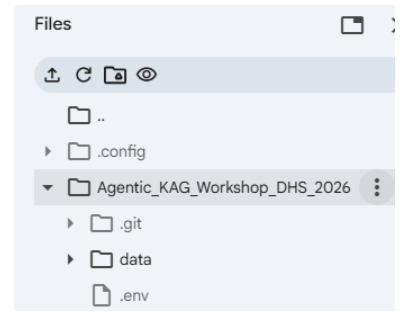

## Install Required Packages

In [ ]:
!pip install -r /content/Agentic_KAG_Workshop_DHS_2026/requirements.txt --quiet

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.7/263.7 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.0/358.0 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.4/669.4 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 22.7 MB/s eta 0:00:00
   ━

## Credentials & Drivers
The Neo4j driver allows you to connect and perform read and write transactions with the database.

In [ ]:
import os

os.chdir('/content/Agentic_KAG_Workshop_DHS_2026/')

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    print("error reading env details")
    pass

# --- Neo4j Sandbox ---
NEO4J_URI      = os.getenv('NEO4J_URI')
NEO4J_USERNAME = os.getenv('NEO4J_USERNAME')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = os.getenv('NEO4J_DATABASE')

# --- OpenAI ---
os.environ.setdefault(
    'OPENAI_API_KEY',
    os.getenv('OPENAI_API_KEY')
)

print('NEO4J_URI :', NEO4J_URI)
print('OPENAI key set:', bool(os.environ.get('OPENAI_API_KEY')))

NEO4J_URI : bolt://44.212.66.123
OPENAI key set: True


In [ ]:
from neo4j import GraphDatabase

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
driver.verify_connectivity()
print('Connected to Neo4j ✔')

Connected to Neo4j ✔


## Initialize OpenAI LLM and Embeddings via neo4j-graphrag
We will use OpenAI **GPT-4.1**. The GraphRAG Python package supports any LLM model, including models from OpenAI, Google VertexAI, Anthropic, Cohere, Azure OpenAI, local Ollama models, and any chat model that works with LangChain. You can also implement a custom interface for any other LLM.

Likewise, we will use OpenAI’s **text-embedding-3-small** for the embedding model, but you can use other embedders from different providers.

In [ ]:
from neo4j_graphrag.llm import OpenAILLM
from neo4j_graphrag.embeddings import OpenAIEmbeddings

llm = OpenAILLM(
    model_name="gpt-5-mini",
)

json_llm = OpenAILLM(
    model_name="gpt-5-mini",
    model_params={"response_format": {"type": "json_object"}
                  }
)

embedder = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

In [ ]:
# Test llm call
llm.invoke("why is sky blue?")

LLMResponse(content='Short answer: because air molecules scatter short wavelengths (blue) of sunlight much more than long wavelengths (red). That process is called Rayleigh scattering.\n\nA bit more detail:\n- Sunlight contains all colors. As it enters the atmosphere it hits molecules and tiny particles and is scattered in different directions.\n- Rayleigh scattering strength varies roughly as 1/(wavelength^4), so blue light (shorter wavelength) is scattered far more than red light. That scattered blue light reaches your eyes from every direction, so the sky looks blue.\n- At sunrise and sunset the sunlight travels through more air, so even more blue is scattered out of the direct beam and the remaining light is red/orange, which is why sunrises and sunsets look red.\n- Clouds look white because their water droplets are large enough to scatter all wavelengths about equally (Mie scattering).\n- You might wonder about violet: it’s scattered even more strongly than blue, but the Sun emits

## Initialize Langfuse Handler for Tracing

In [ ]:
from langfuse.langchain import CallbackHandler
from langfuse import get_client

os.environ["LANGFUSE_PUBLIC_KEY"] = os.getenv("LANGFUSE_PUBLIC_KEY")
os.environ["LANGFUSE_SECRET_KEY"] = os.getenv("LANGFUSE_SECRET_KEY")
os.environ["LANGFUSE_HOST"] = "https://cloud.langfuse.com"

langfuse = get_client()

# Verify connection
if langfuse.auth_check():
    print("Langfuse client is authenticated and ready!")
else:
    print("Authentication failed. Please check your credentials and host.")

langfuse_handler = CallbackHandler()

Langfuse client is authenticated and ready!


# Create a Vector & Fulltext Index

We can create a vector index in Neo4j to allow this retriever to pull back information from the nodes.

-This code interacts with a Neo4j graph database to create and populate indexes for efficient data retrieval.



  - **Create Vector Index:** It creates a vector index on the __Entity__ label, using the vectorProperty for embeddings and cosine similarity. This index allows for efficient similarity searches based on the vector representations of the entities.

  - **Create Full-Text Index:** It creates a full-text index on the __Entity__ label, indexing various text properties like location, theme, bio, etc. This index enables fast keyword-based searches.


  In essence, this code prepares the graph database for efficient searching by creating specialized indexes and ensuring that entities have unique identifiers and associated vector embeddings.



In [ ]:
from neo4j_graphrag.indexes import create_vector_index, create_fulltext_index

VECTOR_INDEX = "movie_embedding_index"
FULLTEXT_INDEX = "movie_text_index"

create_vector_index(
    driver,
    VECTOR_INDEX,
    label="__Entity__",
    embedding_property="embedding",
    dimensions=1536,
    similarity_fn="cosine",
    fail_if_exists=False,
)

create_fulltext_index(
    driver,
    FULLTEXT_INDEX,
    label="__Entity__",
    node_properties=["name", "title", "overview"],  # only text fields
    fail_if_exists=False,
)

Let's goto Neo4j browser to check if our indexes have got created using the below cypher


```
SHOW INDEXES
```



`SHOW INDEXES` is a Neo4j Cypher command that lists all indexes available in the currently selected database. It only displays information and does not create, delete, or modify anything

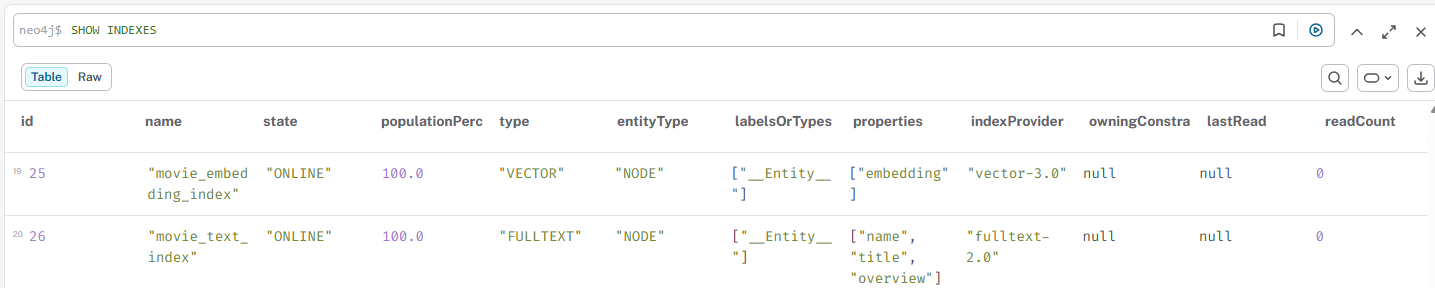

**What is an index?**

Think of an index like the index at the back of a book.

*Without an index:*

```
Search request
      ↓
Check every node in the graph
      ↓
Find matching nodes
```


*With an index:*

```
Search request
      ↓
Look inside the index
      ↓
Jump directly to matching nodes
```

Indexes can therefore make graph queries much faster. Neo4j automatically maintains an index after it has been created.

**What the output tells you**

The result commonly includes:

* name: Name of the index
* state: Whether the index is ready, usually ONLINE
* type: Index type, such as RANGE, FULLTEXT, VECTOR, TEXT, or LOOKUP
* entityType: Whether it indexes nodes or relationships
* labelsOrTypes: The node label or relationship type covered
* properties: Properties included in the index
* populationPercent: How much of the index has been built
* owningConstraint: Whether a constraint created or owns the index
indexProvider: Neo4j component managing the index

# Retrieve Data from Knowledge Graph

# Introduction to Cypher

## What is Cypher?
Cypher is Neo4j's declarative query language for querying graph databases. It works with **nodes**, **relationships**, and **properties**.

## Graph Structure Diagram

```text
   (Person)                 (Movie)
  "Tom Hanks"  ──CAST_IN──> "Forrest Gump"
       │
       │ CAST_IN
       ▼
   (Movie)
"The Terminal"
```

### Equivalent Cypher Representation

```cypher
(Tom Hanks:Person)-[:CAST_IN]->(Forrest Gump:Movie)
```

### Explanation

- **Tom Hanks** is a **Person** node.
- **Forrest Gump** is a **Movie** node.
- **CAST_IN** is the relationship connecting the actor to the movie.
- Each node can have one or more **properties**, such as `name`, `birthYear`, or `rating`.
- Relationships can also contain properties, such as the character played or the role type.

### Graph Components

| Component | Description | Example |
|-----------|-------------|---------|
| **Node** | Represents an entity | `(:Person)` |
| **Label** | Defines the type of node | `Person`, `Movie` |
| **Relationship** | Connects two nodes | `[:CAST_IN]` |
| **Property** | Stores additional information | `name: "Tom Hanks"` |
| **Variable** | Temporary alias used in a query | `p`, `m` |

### Visual Interpretation

```
        Node                 Relationship               Node
    ┌──────────┐          ───────────────▶        ┌──────────┐
    │  Person  │ ---------[:CAST_IN]-----------> │  Movie   │
    └──────────┘                                 └──────────┘
         │                                            │
         │                                            │
   name="Tom Hanks"                          name="Forrest Gump"
```

This graph indicates that the **Person** node representing **Tom Hanks** is connected to the **Movie** node representing **Forrest Gump** through the **CAST_IN** relationship. In Neo4j, queries are written by matching these graph patterns instead of joining tables as in relational databases.

## Neo4J GraphRAG
The GraphRAG Python package provides multiple classes for retrieving data from your knowledge graph, including:

- **Vector Retriever:** performs similarity searches using vector embeddings

- **Vector Cypher Retriever:** combines vector search with retrieval queries in Cypher, Neo4j’s Graph Query language, to traverse the graph and incorporate additional nodes and relationships.

- **Hybrid Retriever:** Combines vector and full-text search.

- **Hybrid Cypher Retriever:** Combines vector and full-text search with Cypher retrieval queries for additional graph traversal.

- **Text2Cypher:** converts natural language queries into Cypher queries to run against Neo4j.

## Vector Retriever

The Vector Retriever uses Approximate Nearest Neighbor (ANN) vector search to retrieve data from your knowledge graph.

You can then instantiate the vector retriever using the code below:

In [ ]:
from neo4j_graphrag.retrievers import VectorRetriever

vector_retriever = VectorRetriever(
   driver,
   index_name="movie_embedding_index",
   embedder=embedder,
   return_properties=["name"],
)

Now, let’s run this retriever with a simple prompt. The retriever can pull back text chunks and vector similarity scores, providing some useful context for answering questions in RAG.

In [ ]:
import json

vector_res = vector_retriever.get_search_results(query_text = "Recommend movies about superheros", top_k=5)

# print output
# Access and print only the records, excluding the metadata
for record in vector_res.records:
    print(record)

<Record node={'name': 'teen superhero'} nodeLabels=['__KGBuilder__', '__Entity__', 'Keyword'] elementId='4:497aeb87-e5ab-4342-9018-2ed1992e8849:127' id='4:497aeb87-e5ab-4342-9018-2ed1992e8849:127' score=0.8069125413894653>
<Record node={'name': 'superhero'} nodeLabels=['__KGBuilder__', '__Entity__', 'Keyword'] elementId='4:497aeb87-e5ab-4342-9018-2ed1992e8849:23' id='4:497aeb87-e5ab-4342-9018-2ed1992e8849:23' score=0.8004292249679565>
<Record node={'name': 'superhero team'} nodeLabels=['__KGBuilder__', '__Entity__', 'Keyword'] elementId='4:497aeb87-e5ab-4342-9018-2ed1992e8849:123' id='4:497aeb87-e5ab-4342-9018-2ed1992e8849:123' score=0.7985118627548218>
<Record node={'name': 'action hero'} nodeLabels=['__KGBuilder__', '__Entity__', 'Keyword'] elementId='4:497aeb87-e5ab-4342-9018-2ed1992e8849:1075' id='4:497aeb87-e5ab-4342-9018-2ed1992e8849:1075' score=0.7780461311340332>
<Record node={'name': 'female superhero'} nodeLabels=['__KGBuilder__', '__Entity__', 'Keyword'] elementId='4:497aeb8

## Vector Cypher Retriever

Another useful retriever to explore is the Vector Cypher Retriever, which lets you use Cypher, Neo4j’s graph query language, to incorporate graph traversal logic after retrieving an initial set of nodes with vector search. Below we create a retriever to obtain relevant nodes via vector search

In [ ]:
from neo4j_graphrag.retrievers import VectorCypherRetriever

vc_retriever = VectorCypherRetriever(
   driver,
   index_name="movie_embedding_index",
   embedder=embedder,
   retrieval_query = """MATCH (p:Person)-[:CAST_IN]->(m:Movie)
RETURN p.name AS actor, count(DISTINCT m) AS movie_count
ORDER BY movie_count DESC
LIMIT 10"""
)

Submitting the same prompt, here’s the context we get back:

In [ ]:
vc_res = vc_retriever.get_search_results(query_text = "List down all Top actors by number of movies?", top_k=3)

# print output
# Access and print only the records, excluding the metadata
for record in vc_res.records:
    print(record)

<Record actor='Prakash Raj' movie_count=21>
<Record actor='Akshay Kumar' movie_count=19>
<Record actor='Vijay Sethupathi' movie_count=17>
<Record actor='Yogi Babu' movie_count=16>
<Record actor='Nassar' movie_count=16>
<Record actor='Fahadh Faasil' movie_count=16>
<Record actor='Kumud Mishra' movie_count=15>
<Record actor='Ajay Devgn' movie_count=15>
<Record actor='Pankaj Tripathi' movie_count=15>
<Record actor='Nawazuddin Siddiqui' movie_count=15>


### Limitations of Vector Retrieval

**Domain-specific limitations**: Vector search can struggle with domain-specific terms or jargon that are not well-represented in the embedding model’s training data.

**Not ideal for precise string matching**: It may not accurately find results when the query depends on exact matches for specific names, numbers, or dates.


## Full-Text Indexes
Fortunately, there is a solution to this issue: full-text indexes. Unlike vector indexes, which match strings based on semantic similarity, full-text indexes match pieces of text based on lexical similarity, meaning they compare the exact wording or text structure.

## Hybrid Retriever




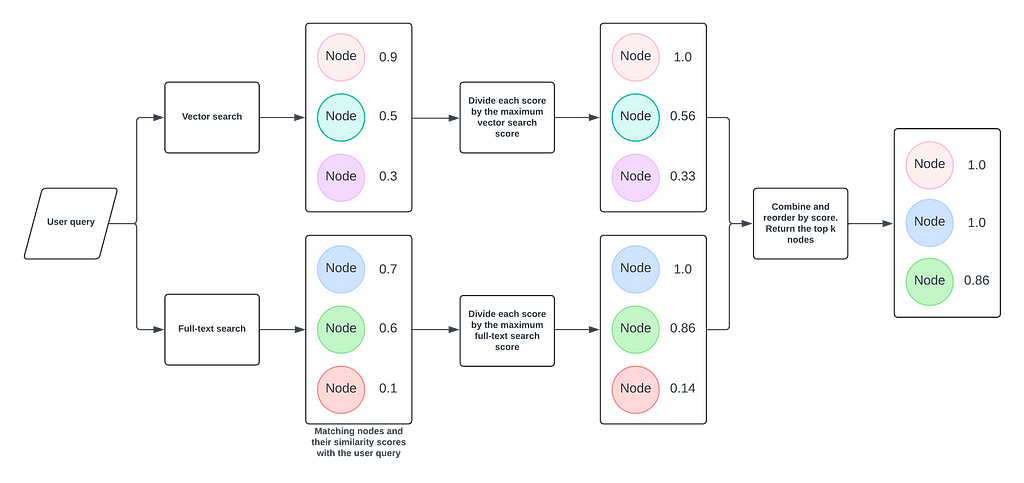

We use full-text indexes for our GraphRAG applications by using the **HybridRetriever class** from the Neo4j GraphRAG Python library. This retriever leverages both a **vector index** and a **full-text index** in a process known as **hybrid search.** It uses the user query to search both indexes, retrieving nodes and their corresponding scores. After normalizing the scores from each set of results, it merges them, ranks the combined results by score, and returns the top matches.

In [ ]:
from neo4j_graphrag.retrievers import HybridRetriever
import json
import ast

hybrid_retriever = HybridRetriever(
    driver=driver,
    vector_index_name="movie_embedding_index",
    fulltext_index_name="movie_text_index",
    embedder=embedder,
    return_properties=["name"]
)

query_text = "Find science fiction movies involving time travel"

try:
    retriever_result = hybrid_retriever.search(
        query_text=query_text,
        top_k=3
    )

    print("Hybrid Retriever Results:\n")

    for item in retriever_result.items:
        data = ast.literal_eval(item.content)
        print(data["name"])

except Exception as e:
    print(f"Error: {e}")

Hybrid Retriever Results:

Science Fiction
time travel
space travel


## Hybrid Cypher Retriever
The HybridCypherRetriever enhances the hybrid search process by adding a graph traversal step. It begins by identifying an initial set of nodes through a combined search over vector and full-text indexes, then uses a specified Cypher query to retrieve additional information from the graph for each of these nodes.


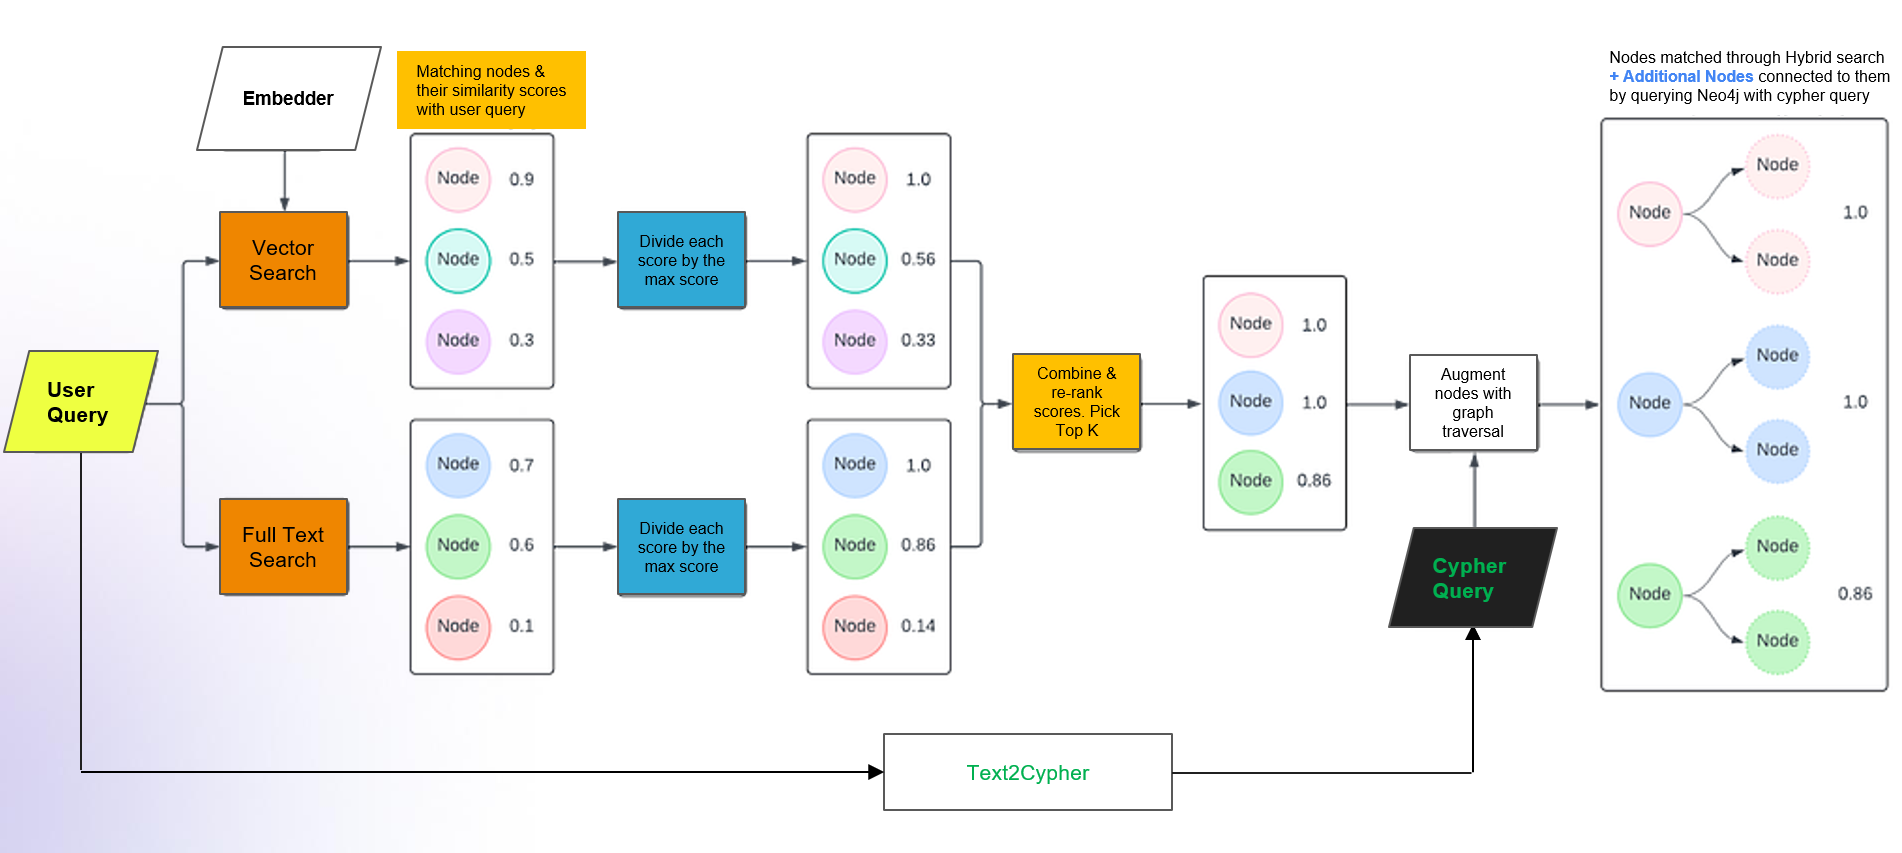

To make use of this retriever, we first need to write a Cypher query to specify exactly what additional information to fetch along with each of the nodes retrieved through hybrid search. Given we are looking to answer questions about actors in movies, we can use the following query:

In [ ]:
retrieval_query = """MATCH (m:Movie)
WHERE m.vote_average > 8
RETURN
    m.title AS title,
    m.vote_average AS vote_average,
    m.release_date AS release_date,
    m.runtime_minutes AS runtime_minutes,
    m.overview AS overview
ORDER BY m.vote_average DESC, m.title ASC"""

We then pass this query to the HybridCypherRetriever with the names of the vector and full-text indexes we want to search.

In [ ]:
from neo4j_graphrag.retrievers import HybridCypherRetriever

hc_retriever = HybridCypherRetriever(
    driver=driver,
    vector_index_name="movie_embedding_index",
    fulltext_index_name="movie_text_index",
    retrieval_query=retrieval_query,
    embedder=embedder,
)
query_text = "List down all the movies with vote average above 8 and is related to time travel?"
retriever_result = hc_retriever.search(query_text=query_text, top_k=3)

# Print only the content of the retrieved items
for item in retriever_result.items:
    print(item.content)

<Record title='Spider-Man: Across the Spider-Verse' vote_average=8.442 release_date='2023-05-31' runtime_minutes=140 overview='After reuniting with Gwen Stacy, Brooklyn’s full-time, friendly neighborhood Spider-Man is catapulted across the Multiverse, where he encounters the Spider Society, a team of Spider-People charged with protecting the Multiverse’s very existence. But when the heroes clash on how to handle a new threat, Miles finds himself pitted against the other Spiders and must set out on his own to save those he loves most.'>
<Record title='Spider-Man: Across the Spider-Verse' vote_average=8.442 release_date='2023-05-31' runtime_minutes=140 overview='After reuniting with Gwen Stacy, Brooklyn’s full-time, friendly neighborhood Spider-Man is catapulted across the Multiverse, where he encounters the Spider Society, a team of Spider-People charged with protecting the Multiverse’s very existence. But when the heroes clash on how to handle a new threat, Miles finds himself pitted a

## Text2Cypher Retriever

**Recap - What is Cypher?**
 Cypher is the primary query language used with graph databases, and an example can be seen below.



```
MATCH (p:Person)-[l:LIVES_AT]->(a:Address)
WHERE p.name = "Bob" and l.since >= date('2025-01-01')
RETURN a.address as address
```



Text2Cypher retriever first asks an LLM to generate a Cypher query to fetch the exact information required to answer the question from the database. Then this query is executed and the resulting records are added to the context for the LLM to write the answer to the initial user question.

The workflow for generating Cypher queries from natural language questions can
be broken down into the following steps:
- Retrieve the question from the user.
- Retrieve the schema of the knowledge graph.
- Define other useful information like terminology mappings, format instructions, and few-shot examples.
- Generate the prompt for the LLM.
- Pass the prompt to the LLM to generate the Cypher query.


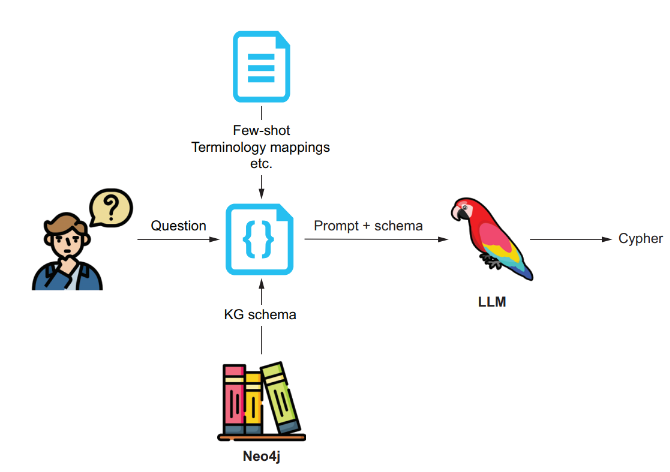

In [ ]:
from neo4j_graphrag.retrievers import Text2CypherRetriever
from neo4j_graphrag.schema import get_schema

import prompts
from examples import examples

schema = get_schema(driver)

t2c_retriever = Text2CypherRetriever(
    driver=driver,
    llm=llm,
    neo4j_schema=schema,
    custom_prompt=prompts.custom_text2cypher_prompt,
    examples=examples,
)

# Define a sample query in natural language
query_text = "List the top 10 highest-rated Hindi movies"

# Use the retriever to convert the natural language query to a Cypher query and execute it
response = t2c_retriever.search(query_text=query_text)

# Print the generated Cypher query and the results
print("Generated Cypher Query:")
print(response.metadata['cypher'])
print("\nResults:")
for record in response.items:
    print(record.content)

KeyError: ' '

# GraphRAG

To turn the retriever search into a full GraphRAG pipeline, we simply add the following code:

Let's continue by running the GraphRAG pipeline with each of the defined retrievers.

In [ ]:
from neo4j_graphrag.generation import GraphRAG
from IPython.display import display, Markdown
import json

def query_graph(retriever, llm, query_text, retriever_config):
  """Queries the graph using a GraphRAG pipeline.

  Args:
    retriever: The retriever to use.
    llm: The language model to use.
    query_text: The query text.
    retriever_config: The retriever configuration.

  Returns:
    The response from the GraphRAG pipeline.
  """
  # Initialize the RAG pipeline
  rag = GraphRAG(retriever=retriever, llm=llm)

  # Query the graph
  response = rag.search(query_text=query_text,
                        retriever_config=retriever_config,
                        return_context=True,
                        response_fallback="I can not answer this question because I have no relevant context.",
                        # config={"callbacks": [langfuse_handler]}
                        )
  return response.answer

query_text = "List down movies similar to Interstellar?"
top_k_value = 5

# Get results from Vector Retriever using query_graph function
display(Markdown("### Vector Retriever Results (using GraphRAG)"))
response = query_graph(vector_retriever, llm, query_text, {"top_k": top_k_value})
display(Markdown(response))

# Get results from Vector Cypher Retriever using query_graph function
display(Markdown("### Vector Cypher Retriever Results (using GraphRAG)"))
response = query_graph(vc_retriever, llm, query_text, {"top_k": top_k_value})
display(Markdown(response))

# Get results from Text2Cypher Retriever using the query_graph function
display(Markdown("### Text2Cypher Retriever Results (using GraphRAG)"))
# response = query_graph(t2c_retriever, llm, query_text, {})
# display(Markdown(response))

# Get results from Hybrid Retriever using query_graph function
display(Markdown("### Hybrid Retriever Results (using GraphRAG)"))
response = query_graph(hybrid_retriever, llm, query_text, {"top_k": top_k_value})
display(Markdown(response))

# Get results from Hybrid Cypher Retriever using the query_graph function
display(Markdown("### Hybrid Cypher Retriever Results (using GraphRAG)"))
response = query_graph(hc_retriever, llm, query_text, {"top_k": top_k_value})
display(Markdown(response))

### Vector Retriever Results (using GraphRAG)

Here are movies you might enjoy if you liked Interstellar — each with a short reason why it’s a good match:

- 2001: A Space Odyssey (1968) — epic, philosophical, and visually immersive space odyssey that explores humanity and the unknown.  
- Contact (1997) — science-driven first-contact story with strong emotional and philosophical themes.  
- The Martian (2015) — realistic, science-based survival story with NASA mission feel and human ingenuity.  
- Gravity (2013) — intense, immersive survival-in-space drama with spectacular visuals and emotional stakes.  
- Arrival (2016) — thoughtful, high-concept sci-fi about language, time, and human connection.  
- Solaris (1972 or 2002) — introspective, psychological exploration of memory, grief, and identity in space.  
- Moon (2009) — intimate, character-driven sci-fi about isolation, identity, and corporate missions on the lunar surface.  
- Sunshine (2007) — mission-to-save-the-sun thriller with existential tension and strong visuals.  
- Ad Astra (2019) — introspective, father/son-focused space journey with emotional and psychological depth.  
- Europa Report (2013) — tense, realistic mission film about exploration and scientific discovery with a found-footage style.

If you want, I can:  
- recommend which of these to watch first based on what you liked most about Interstellar (visuals, emotional story, hard science, etc.),  
- find where each movie is streaming, or  
- look for similar titles from the companies you mentioned (Beyond The Cloud Motion Pictures, Next Gen Films, Full Moon Cinema, Northern Lights Films). Which would you like?

### Vector Cypher Retriever Results (using GraphRAG)

I can’t find any movie information in the data you provided — it only lists actors and how many movies they’ve done (e.g., Prakash Raj 21, Akshay Kumar 19, etc.). Because of that, I can’t produce a list of movies similar to Interstellar from this context.

Would you like me to:
- Give recommendations for movies similar to Interstellar using general knowledge (science-heavy sci‑fi, space exploration, emotional/epic scope), or
- Search a specific dataset or list you can provide?

If you want recommendations now, tell me what “similar” means to you (scientific realism, mind-bending plot, emotional family storyline, Christopher Nolan style, etc.), and I’ll suggest films.

### Text2Cypher Retriever Results (using GraphRAG)

### Hybrid Retriever Results (using GraphRAG)

I can’t find any movie titles in the provided context — it only contains studio/label names (e.g., "Beyond The Cloud Motion Pictures", "Next Gen Films", "Full Moon Cinema") and one empty entry. So I can’t list similar movies using that data.

If you’d like, I can list movies similar to Interstellar from general knowledge. Common recommendations:
- Inception (2010) — mind-bending sci‑fi from Christopher Nolan with emotional stakes.
- Contact (1997) — thoughtful, science-driven first-contact drama.
- The Martian (2015) — survival-focused, scientifically grounded space film.
- 2001: A Space Odyssey (1968) — philosophical, visually grand space epic.
- Gravity (2013) — intense, realistic space survival drama.
- Arrival (2016) — cerebral sci‑fi about language, time, and humanity.
- Solaris (1972/2002) — psychological, introspective space drama.
- Ad Astra (2019) — introspective space journey with personal themes.
- Moon (2009) — intimate, character-driven sci‑fi on a lunar base.

Tell me if you want recommendations filtered by tone (e.g., action, philosophical, scientific), era, or streaming availability.

### Hybrid Cypher Retriever Results (using GraphRAG)

From the provided list, the closest matches to Interstellar are:

- Spider-Man: Across the Spider-Verse (2023) — shares strong sci-fi/fantasy elements (multiverse) and an emotional, character-driven story.  
- Lion (2016) — an epic, emotional journey about loss and the search for home/family, similar in tone to Interstellar’s human core.  
- Kumbalangi Nights (2019) — a deeply character-driven, emotionally resonant drama focused on relationships and redemption.  
- Oh My Kadavule (2020) — explores love, second chances and personal transformation (thematically resonant with Interstellar’s emotional stakes).

Note: none of the movies in the provided list are a direct match for Interstellar’s space exploration / hard sci-fi scope — Spider-Man is the nearest in genre. If you’d like, I can recommend more closely matching sci-fi/space films outside this dataset.